# Задание 1 (Вариант 5)

$f_θ(x) = \frac{1}{(k-1)!θ^k} x^{k-1} e^{-x/θ} \mathbf{1}(x > 0)$

**Параметры эксперимента:**

$θ = 2$ (неизвестный параметр)

$k = 3$


## Теоретический анализ

Данное распределение является гамма-распределением - $Γ(k, θ)$

### Теоретический первый момент

$\qquad E[X] = k \cdot θ$

### Метод моментов:
Приравниваем теоретический момент к выборочному:

$\qquad k = 3$

$\qquad \bar{X} = k\hat{θ} = 3\hat{θ}$

Получаем оценку методом моментов:

$\qquad \hat{θ} = \frac{\bar{X}}{k} = \frac{\bar{X}}{3}$

### Свойства оценки:

**Несмещенность**

$\qquad E[\hat{θ}] = \frac{E[\bar{X}]}{k} = \frac{kθ}{k} = θ$

**Состоятельность**

$\qquad$ По ЗБЧ $\bar{X} \xrightarrow{P} kθ$, значит $\hat{θ} \xrightarrow{P} θ$

**Дисперсия**

$\qquad \text{Var}(\hat{θ}) = \frac{\text{Var}(\bar{X})}{k^2} = \frac{k*θ^2}{n*k^2} = \frac{θ^2}{nk}$

**MSE**

$\qquad \text{MSE}(\hat{θ}) = \text{Var}(\hat{θ}) + \text{Bias}^2(\hat{θ}) = \frac{θ^2}{nk} + 0^2 = \frac{θ^2}{nk}$


In [155]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

np.random.seed(0)


## Параметры эксперимента

In [156]:
K = 3
THETA = 2

# Функция для генерации выборки из гамма-распределения
def generate_gamma_sample(n, k, theta):
    return np.random.gamma(shape=k, scale=theta, size=n)

# Функция для вычисления оценки θ методом моментов
def estimate_theta(sample, k = K):
    sample_mean = np.mean(sample)
    theta_hat = sample_mean / k
    return theta_hat

# Функция для вычисления теоретических характеристик оценки
def theoretical_properties(n, k, theta):
    bias = 0
    variance = theta**2 / (n * k)
    mse = variance + bias*bias
    return {
        'n': n,
        'mean': theta,
        'bias': bias,
        'var': variance,
        'mse': mse,
    }


## Эксперимент

- ### Зададим массив объемов выборки
- ### Для каждого объема сгенерируем t выборок и вычислим оценки
- ### Построим визуализации


In [157]:
SAMPLE_SIZES = [10, 20, 50, 100, 200, 500, 1000, 10000]
M = 1000

CRIT_ERR_BOUND = 0.1

EMP_DATA = []
TH_DATA = []
ESTIMATES = {}

for n in SAMPLE_SIZES:
    errors = []
    ESTIMATES[n] = []

    # Процент критических ошибок
    crit_err = 0

    # Генерируем m выборок размера n
    for _ in range(M):
        sample = generate_gamma_sample(n, K, THETA)
        theta_hat = estimate_theta(sample, K)
        error = np.abs(theta_hat - THETA)
        ESTIMATES[n].append(theta_hat)
        errors.append(error)
        if error > CRIT_ERR_BOUND:
            crit_err += 1

    crit_err /= M
    errors = np.array(errors)

    # Эмпирические оценки
    ESTIMATES[n] = np.array(ESTIMATES[n])
    emp_mean = np.mean(ESTIMATES[n])
    empirical_bias = np.mean(errors)
    empirical_variance = np.var(ESTIMATES[n], ddof=1)
    empirical_mse = np.mean(errors**2)
    EMP_DATA.append({
        'n': n,
        'mean': emp_mean,
        'bias': empirical_bias,
        'var': empirical_variance,
        'mse': empirical_mse,
        'crit_err': crit_err,
    })

    # Теоретические оценки
    TH_DATA.append(theoretical_properties(n, K, THETA))

df_emp_summary = pd.DataFrame(EMP_DATA)
print("EMPIRICAL ESTIMATIONS:")
print(df_emp_summary.round(6))
print()

df_th_summary = pd.DataFrame(TH_DATA)
print("THEORETICAL ESTIMATIONS:")
print(df_th_summary.round(6))


EMPIRICAL ESTIMATIONS:
       n      mean      bias       var       mse  crit_err
0     10  1.985497  0.282684  0.124056  0.124142     0.787
1     20  2.003392  0.203676  0.066429  0.066374     0.694
2     50  2.010268  0.131748  0.027509  0.027587     0.537
3    100  1.993729  0.091099  0.012823  0.012850     0.391
4    200  2.003940  0.064957  0.006757  0.006766     0.204
5    500  2.001773  0.042537  0.002787  0.002787     0.056
6   1000  1.998656  0.029696  0.001377  0.001377     0.004
7  10000  1.999803  0.009094  0.000129  0.000129     0.000

THEORETICAL ESTIMATIONS:
       n  mean  bias       var       mse
0     10     2     0  0.133333  0.133333
1     20     2     0  0.066667  0.066667
2     50     2     0  0.026667  0.026667
3    100     2     0  0.013333  0.013333
4    200     2     0  0.006667  0.006667
5    500     2     0  0.002667  0.002667
6   1000     2     0  0.001333  0.001333
7  10000     2     0  0.000133  0.000133


## Визуализация: Распределение оценок

- ### Проанализируем распределение оценок для нескольких размеров выборки

$\qquad \hat{θ} = \frac{\bar{X}}{k} \xrightarrow{} U \sim N\left(θ, \frac{θ^2}{nk}\right)$


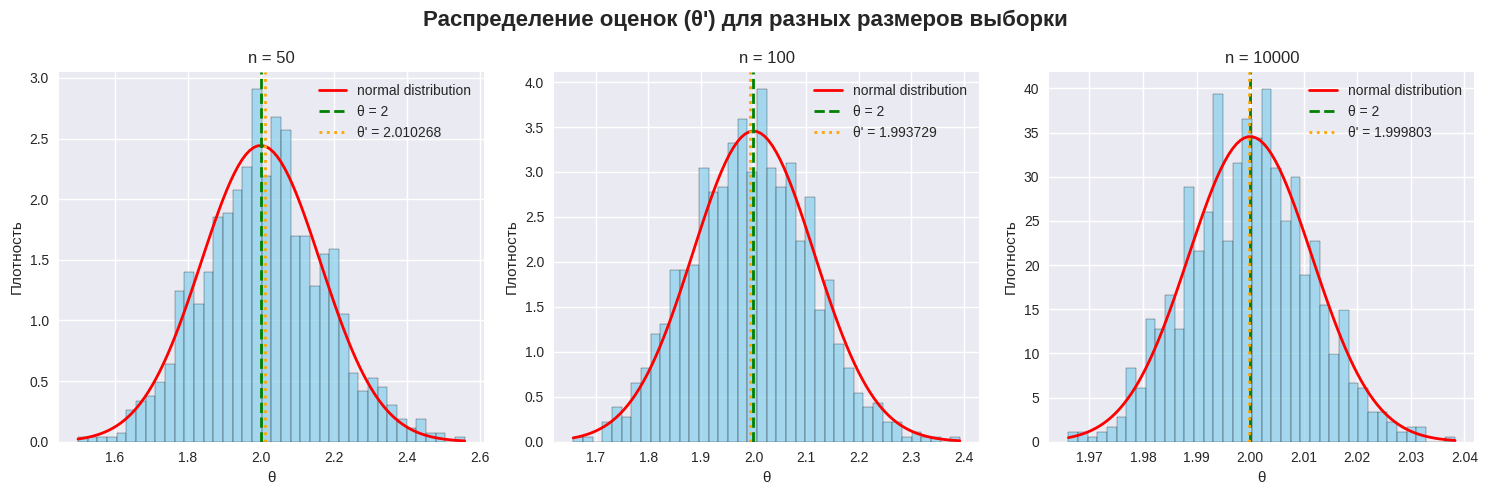

In [158]:
SIZES = [50, 100, 10000]

fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 5))
fig.suptitle("Распределение оценок (θ') для разных размеров выборки", fontsize=16, fontweight='bold')

for i, n in enumerate(SIZES):
    estimates = ESTIMATES[n]
    axes[i].hist(estimates, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='black')

    # Теоретическое нормальное распределение
    x_range = np.linspace(estimates.min(), estimates.max(), 100)
    theoretical_pdf = stats.norm.pdf(x_range, THETA, np.sqrt((THETA * THETA) / (n * K)))
    axes[i].plot(x_range, theoretical_pdf, 'r-', linewidth=2, label=f'normal distribution')

    # Истинное значение
    axes[i].axvline(x=THETA, color='green', linestyle='--', linewidth=2, label=f'θ = {THETA}')

    # Эмпирическое среднее
    emp_mean = EMP_DATA[SAMPLE_SIZES.index(n)]['mean']
    axes[i].axvline(x=emp_mean, color='orange', linestyle=':', linewidth=2, label=f"θ' = {emp_mean:.6f}")

    axes[i].set_title(f'n = {n}')
    axes[i].set_xlabel('θ')
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


## Выводы и заключение

### Результаты эксперимента:

**1. Несмещенность**
- Эмпирическое смещение близко к 0 для всех размеров выборки
- Теоретическое смещение = 0 (доказано аналитически)

**2. Состоятельность**
- Дисперсия убывает как $\frac{θ^2}{nk} = \frac{4}{3n}$
- $MSE = Var \xrightarrow{} 0$
- Доля больших ошибок уменьшается с ростом n

**3. Эффективность**
- Оценка асимптотически нормальна

### Практические выводы:

- Для надежной оценки лучше брать n >= 1000
- Асимптотическая нормальность подтверждается экспериментально
- Метод моментов дает простую и эффективную оценку для гамма-распределения
